In [ ]:
from nrem_analysis.constant import RAW_DIR, PROCESSED_DIR, MOUSE_IDS_DUAL
from nrem_analysis.utils import plot_intervals

from replay_trajectory_classification import (
    SortedSpikesClassifier,
    Environment,
    RandomWalk,
    Uniform,
    Identity,
    DiagonalDiscrete,
    make_track_graph,
)

import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import cmap

data_dir = RAW_DIR / "dual"
mouse_id = "99b"

STATE_PROB = 0.99
STATE_NAMES = ["continuous", "fragmented", "stationary"]
BIN_SIZE_S = 0.001
DECODING_WINDOW = 500

session = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "session.npz")
sleep = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "sleep.npz")
hd_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "hd_units.npz")
turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")
head_direction = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "head_direction.npz")

cyclic_cmap = cmap.Colormap('cmocean:phase').to_mpl()
seq_cmap = cmap.Colormap('cmasher:tropical').to_mpl()

In [416]:
STATE_PROB = 0.98

### Train the state classifier

In [417]:
def get_environment(num_nodes: int = 360, place_bin_size: float = 1.0):
    radius = 180 / np.pi
    angle = np.linspace(2 * np.pi, 0, num=num_nodes, endpoint=False)
    node_positions = np.stack((radius * np.cos(angle), radius * np.sin(angle)), axis=1)

    node_ids = np.arange(node_positions.shape[0])
    edges = np.stack((node_ids, np.roll(node_ids, shift=1)), axis=1)

    track_graph = make_track_graph(node_positions, edges)

    n_nodes = len(track_graph.nodes)
    edge_order = np.stack(
        (np.roll(np.arange(n_nodes - 1, -1, -1), 1),
         np.arange(n_nodes - 1, -1, -1)),
        axis=1,
    )

    return Environment(
        place_bin_size=place_bin_size,
        track_graph=track_graph,
        edge_order=edge_order,
        edge_spacing=0,
    )

def fit_classifier(head_direction, train_spikes):
    environment = get_environment()
    continuous_transition_types = [
        [RandomWalk(movement_var=2.0), Uniform(), Identity()],
        [Uniform(),                    Uniform(), Uniform()],
        [RandomWalk(movement_var=2.0), Uniform(), Identity()],
    ]
    classifier = SortedSpikesClassifier(
        environments=environment,
        continuous_transition_types = continuous_transition_types,
        discrete_transition_type=DiagonalDiscrete(STATE_PROB),
        )
    classifier.fit(head_direction, train_spikes)
    return classifier

train_ep = head_direction.time_support
train_ep = nap.IntervalSet(train_ep.start-BIN_SIZE_S/2, train_ep.end)
train_data = hd_units.count(bin_size=BIN_SIZE_S, ep=train_ep, time_units="s").astype(np.bool_)

classifier = fit_classifier(head_direction.values, train_data.values)

c:\Users\iii9781\nrem_analysis\.venv\Lib\site-packages\replay_trajectory_classification\likelihoods\spiking_likelihood_kde.py:119: RuntimeWarning: divide by zero encountered in log
  return np.exp(np.log(mean_rate) + np.log(marginal_density) - np.log(occupancy))


### Inference


In [406]:
ep = sleep[sleep['state'] == 'nrem'][0]
spikes = hd_units.count(bin_size=BIN_SIZE_S, ep=ep, time_units="s").astype(np.bool_)
result = classifier.predict(spikes=spikes, time=spikes.times(), state_names=STATE_NAMES)

states = nap.TsdFrame(t=result['time'].to_numpy(), d=result['acausal_posterior'].sum(dim='position').to_numpy(), columns=result['state'])
position = nap.Tsd(t=result['time'].to_numpy(), d=result['acausal_posterior'].sum(dim='state').argmax(dim='position').to_numpy(),)
pref_angle = tcs.argmax(dim='position').to_numpy()


  0%|          | 0/59 [00:00<?, ?it/s]

In [412]:
sc_spikes = turn_units.restrict(ep)
hd_spikes = hd_units.restrict(ep)

pop=sc_spikes.count(bin_size=0.001).sum(axis=1)
pop = pop / 0.001
pop = pop.smooth(std=0.05)

In [414]:
window_size = 10 * 1000
offset = 20 * 1000
start, end = offset, offset + window_size

0.95 state prob

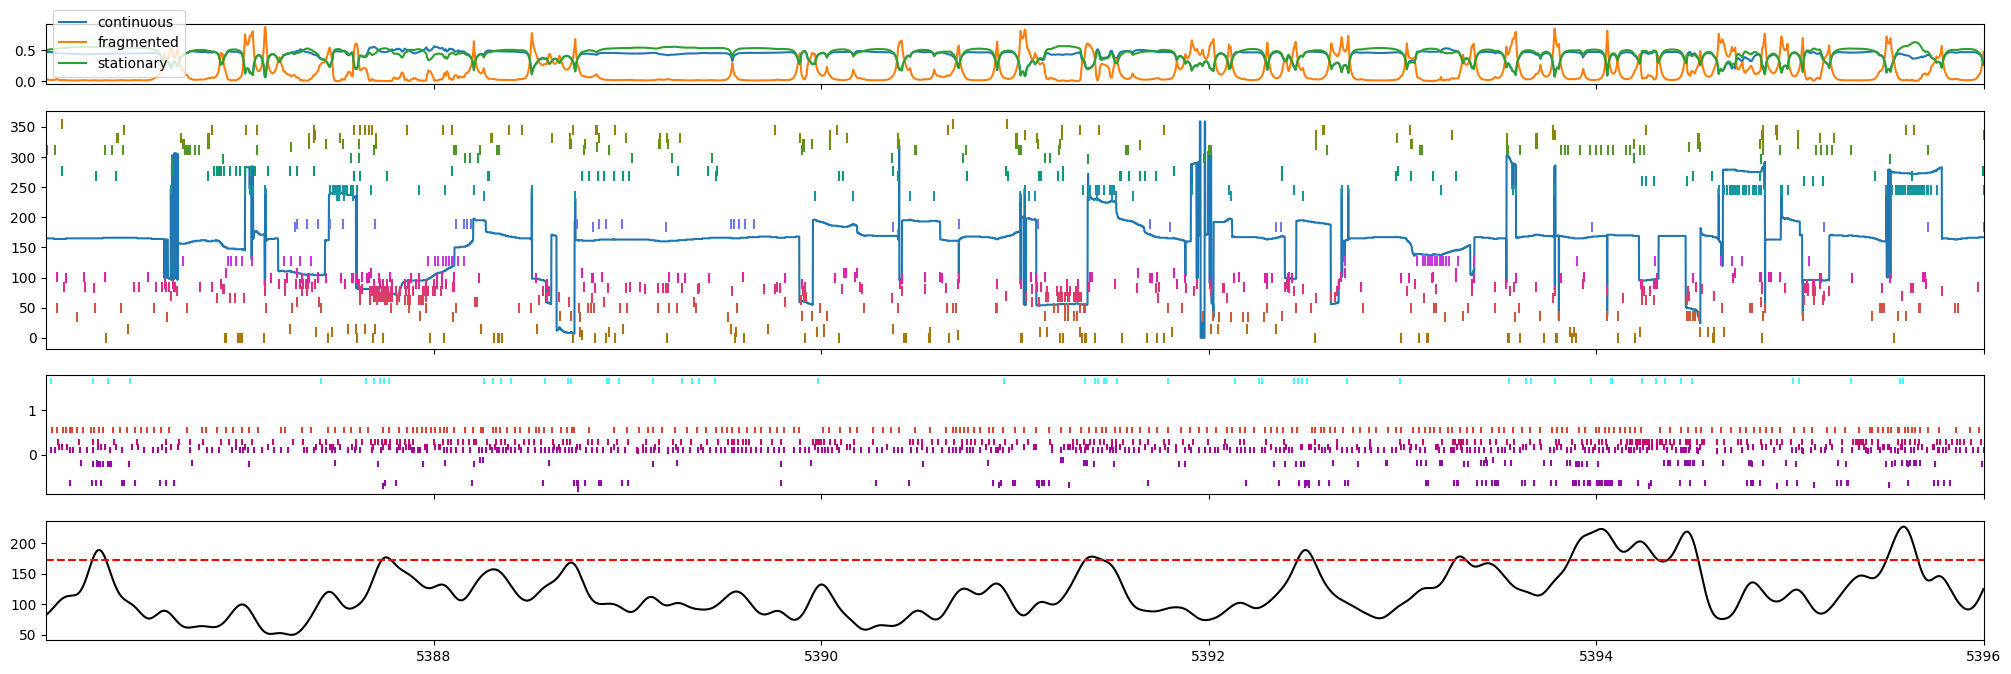

In [415]:
f, ax = plt.subplots(4, 1, figsize=(25, 8), sharex=True, gridspec_kw={'height_ratios': [0.2, 0.8, 0.4, 0.4]})

start, end = start + window_size//2, end + window_size//2

ax[0].plot(states[start:end], label=states.columns.values)
ax[0].legend()

ax[1].plot(position[start:end])

for i, n in enumerate(hd_spikes.keys()):
    pa = pref_angle[n].item()
    ax[1].plot(hd_spikes[n].fillna(pa), '|', color=cyclic_cmap(pa/360), markersize=7, markeredgewidth=1.5)

ax[1].set_xlim(states.index[start], states.index[end])

for i, n in enumerate(sc_spikes.keys()):
    ti = sc_spikes['turn_index'][n].item()
    ax[2].plot(sc_spikes[n].fillna(ti), '|', color=seq_cmap(ti/max(sc_spikes['turn_index'])), markersize=5, markeredgewidth=1.5)
ax[3].plot(pop[start:end], 'k')
ax[3].axhline(pop.mean() + 1.5*pop.std(), color='r', linestyle='--')


0.99 state prob

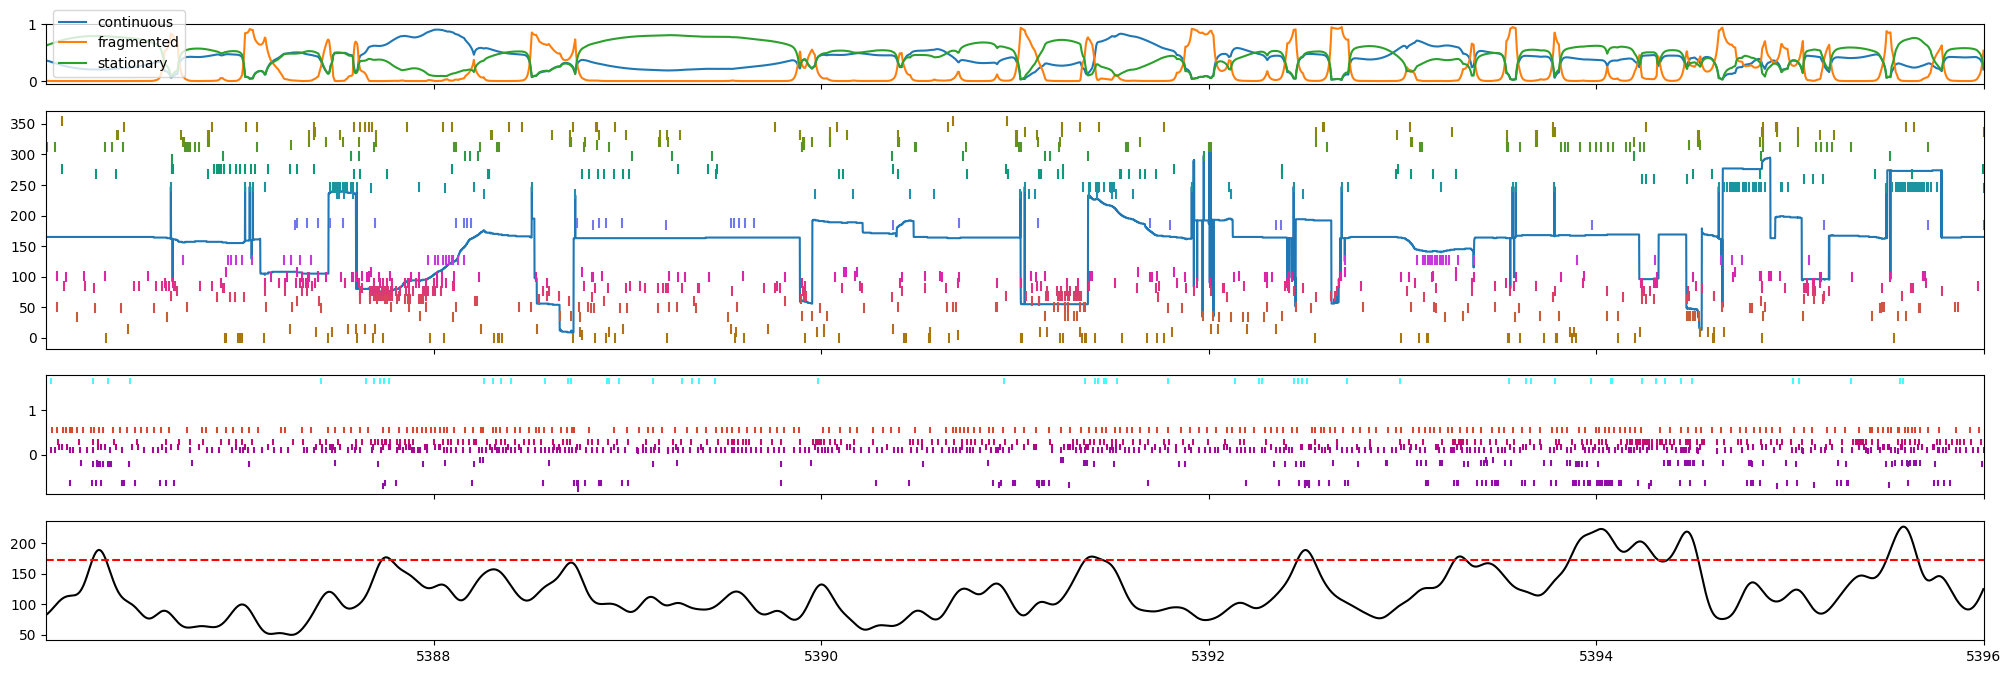

In [405]:
f, ax = plt.subplots(4, 1, figsize=(25, 8), sharex=True, gridspec_kw={'height_ratios': [0.2, 0.8, 0.4, 0.4]})

start, end = start + window_size//2, end + window_size//2

ax[0].plot(states[start:end], label=states.columns.values)
ax[0].legend()

ax[1].plot(position[start:end])

for i, n in enumerate(spikes.keys()):
    pa = pref_angle[n].item()
    ax[1].plot(spikes[n].fillna(pa), '|', color=cyclic_cmap(pa/360), markersize=7, markeredgewidth=1.5)

ax[1].set_xlim(states.index[start], states.index[end])

for i, n in enumerate(sc_spikes.keys()):
    ti = sc_spikes['turn_index'][n].item()
    ax[2].plot(sc_spikes[n].fillna(ti), '|', color=seq_cmap(ti/max(sc_spikes['turn_index'])), markersize=5, markeredgewidth=1.5)
ax[3].plot(pop[start:end], 'k')
ax[3].axhline(pop.mean() + 1.5*pop.std(), color='r', linestyle='--')
